In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import json
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# === Load pitch data ===
# Load pitch data
with open("/content/only_pitch_cents_grouped.json", "r") as f:
    pitch_data = json.load(f)

# Convert to tensors
pitch_sequences = [torch.tensor(seq, dtype=torch.float32) for seq in pitch_data]

# 🔁 Normalize (zero mean, unit variance)
all_values = torch.cat(pitch_sequences)
mean = all_values.mean()
std = all_values.std()

pitch_sequences = [(seq - mean) / std for seq in pitch_sequences]


# === Dataset and Loader ===
class PhraseDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    lengths = [len(seq) for seq in batch]
    padded = pad_sequence(batch, batch_first=True)
    return padded, torch.tensor(lengths)

dataset = PhraseDataset(pitch_sequences)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)


In [ ]:
# === Autoencoder ===
class AE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(AE, self).__init__()
        self.encoder_rnn = nn.GRU(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc_latent = nn.Linear(hidden_dim, latent_dim)

        self.fc_decoder = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn = nn.GRU(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def encode(self, x, lengths):
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, h_n = self.encoder_rnn(packed)
        h_n = h_n.squeeze(0)
        z = self.fc_latent(h_n)
        return z

    def decode(self, z, seq_len):
        hidden = self.fc_decoder(z).unsqueeze(0)  # (1, batch, hidden_dim)
        inputs = torch.zeros((z.size(0), seq_len, 1)).to(z.device)
        output, _ = self.decoder_rnn(inputs, hidden)
        return self.output_layer(output).squeeze(-1)

    def forward(self, x, lengths):
        z = self.encode(x, lengths)
        max_len = x.size(1)
        recon = self.decode(z, max_len)
        return recon, z

# === Loss ===
def loss_function(recon_x, x, lengths):
    mask = torch.arange(x.size(1)).unsqueeze(0) < lengths.unsqueeze(1)
    mask = mask.to(x.device)
    return F.mse_loss(recon_x[mask], x[mask])

In [ ]:
# === Training ===
hidden_dim = 64
latent_dim = 8
model = AE(input_dim=1, hidden_dim=hidden_dim, latent_dim=latent_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch, lengths in dataloader:
        batch = batch.unsqueeze(-1)
        optimizer.zero_grad()
        recon, _ = model(batch, lengths)
        loss = loss_function(recon, batch.squeeze(-1), lengths)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")


Epoch 1, Loss: 1.2976
Epoch 2, Loss: 1.2853
Epoch 3, Loss: 1.1579
Epoch 4, Loss: 0.9368
Epoch 5, Loss: 1.0085
Epoch 6, Loss: 0.9192
Epoch 7, Loss: 1.0175
Epoch 8, Loss: 1.0059
Epoch 9, Loss: 0.9498
Epoch 10, Loss: 1.4113
Epoch 11, Loss: 0.9339
Epoch 12, Loss: 1.4250
Epoch 13, Loss: 1.0900
Epoch 14, Loss: 0.8583
Epoch 15, Loss: 0.8204
Epoch 16, Loss: 0.8546
Epoch 17, Loss: 0.8171
Epoch 18, Loss: 0.7051
Epoch 19, Loss: 0.9770
Epoch 20, Loss: 0.7097


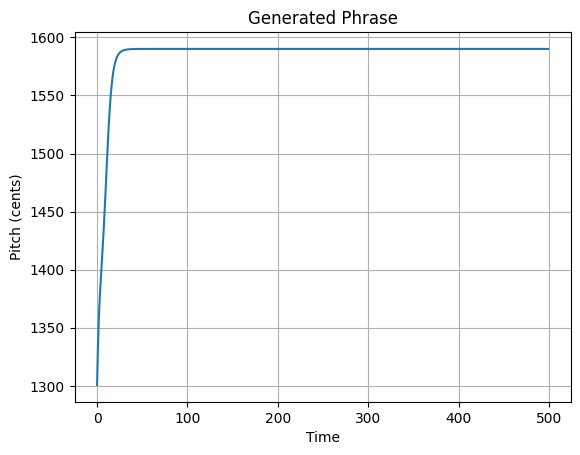

In [ ]:
# === Generation ===
def generate_new_phrase(model, seq_len=500, device='cpu'):
    model.eval()
    with torch.no_grad():
        z = torch.randn(1, model.latent_dim).to(device)
        generated = model.decode(z, seq_len=seq_len).squeeze(0).cpu().numpy()
        denormalized = generated * std.item() + mean.item()  # <-- Fixed here
        return denormalized

# === Example usage ===
generated_phrase = generate_new_phrase(model, seq_len=500, device=device)
plt.plot(generated_phrase)
plt.title("Generated Phrase")
plt.xlabel("Time")
plt.ylabel("Pitch (cents)")
plt.grid()
plt.show()